# Przewidywanie cen samochodów na polskim rynku wtórnym

## 1. Wybór zestawu danych

**Zbiór danych:** [Car Prices Poland](https://www.kaggle.com/datasets/aleksandrglotov/car-prices-poland/data)

**Problem biznesowy:** automatyzacja i obiektywizacja wyceny samochodów używanych na polskim rynku. Takie rozwiązanie może wspierać komisy, platformy ogłoszeniowe, firmy ubezpieczeniowe oraz osoby prywatne przy ocenie, czy dana oferta jest rynkowo uzasadniona.

**Uzasadnienie wyboru:** zbiór zawiera rzeczywiste ogłoszenia samochodowe z Polski, a więc jest adekwatny do problemu biznesowego. Dane obejmują cechy techniczne pojazdu (`year`, `mileage`, `vol_engine`, `fuel`), cechy kategoryczne (`mark`, `model`, `generation_name`) oraz lokalizację (`city`, `province`). Zmienną docelową jest `price`, dlatego problem można sformułować jako zadanie regresji nadzorowanej.


In [4]:
# Uruchom tę komórkę, jeśli w środowisku brakuje wymaganych bibliotek.
# Działa także w środowiskach Jupyter uruchamianych przez uv, gdzie moduł pip może nie być dostępny.
import importlib.util
import shutil
import subprocess
import sys

packages = ["pandas", "numpy", "matplotlib", "seaborn"]
missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]

if missing:
    uv_path = shutil.which("uv")
    if uv_path:
        subprocess.check_call([uv_path, "pip", "install", "--python", sys.executable, *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Wszystkie wymagane biblioteki są już zainstalowane.")


Wszystkie wymagane biblioteki są już zainstalowane.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "Car_Prices_Poland_Kaggle.csv"
df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Liczba rekordów: {df.shape[0]:,}")
print(f"Liczba kolumn: {df.shape[1]}")
display(df.head())


Liczba rekordów: 117,927
Liczba kolumn: 10


,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price
0,opel,combo,gen-d-2011,2015,139568,1248,Diesel,Janki,Mazowieckie,35900
1,opel,combo,gen-d-2011,2018,31991,1499,Diesel,Katowice,Śląskie,78501
2,opel,combo,gen-d-2011,2015,278437,1598,Diesel,Brzeg,Opolskie,27000
3,opel,combo,gen-d-2011,2016,47600,1248,Diesel,Korfantów,Opolskie,30800
4,opel,combo,gen-d-2011,2014,103000,1400,CNG,Tarnowskie Góry,Śląskie,35900


## 2. Analiza zbioru danych

Celem tej części jest sprawdzenie struktury danych, typów zmiennych, braków, rozkładów najważniejszych cech oraz zależności między zmiennymi. Analiza pozwala ocenić, czy zbiór nadaje się do budowy modelu AI i jakie przygotowanie danych będzie potrzebne przed implementacją modeli.


In [18]:
print("--- INFORMACJE O ZBIORZE ---")
df.info()

print("\n--- TYPY ZMIENNYCH ---")
types_summary = pd.DataFrame({
    "kolumna": df.columns,
    "typ": df.dtypes.astype(str).values,
    "liczba_unikalnych": df.nunique(dropna=True).values,
    "przykładowe_wartości": [df[col].dropna().astype(str).unique()[:5].tolist() for col in df.columns],
})
display(types_summary)


--- INFORMACJE O ZBIORZE ---
<class 'pandas.DataFrame'>
RangeIndex: 117927 entries, 0 to 117926
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   mark             117927 non-null  str  
 1   model            117927 non-null  str  
 2   generation_name  87842 non-null   str  
 3   year             117927 non-null  int64
 4   mileage          117927 non-null  int64
 5   vol_engine       117927 non-null  int64
 6   fuel             117927 non-null  str  
 7   city             117927 non-null  str  
 8   province         117927 non-null  str  
 9   price            117927 non-null  int64
dtypes: int64(4), str(6)
memory usage: 9.0 MB

--- TYPY ZMIENNYCH ---


,kolumna,typ,liczba_unikalnych,przykładowe_wartości
0,mark,str,23,"[opel, audi, bmw, volkswagen, ford]"
1,model,str,328,"[combo, vectra, adam, agila, ampera]"
2,generation_name,str,364,"[gen-d-2011, gen-b-1995-2002, gen-c-2002-2008,..."
3,year,int64,54,"[2015, 2018, 2016, 2014, 2017]"
4,mileage,int64,35394,"[139568, 31991, 278437, 47600, 103000]"
5,vol_engine,int64,508,"[1248, 1499, 1598, 1400, 1368]"
6,fuel,str,6,"[Diesel, CNG, Gasoline, LPG, Hybrid]"
7,city,str,4427,"[Janki, Katowice, Brzeg, Korfantów, Tarnowskie..."
8,province,str,23,"[Mazowieckie, Śląskie, Opolskie, Dolnośląskie,..."
9,price,int64,9310,"[35900, 78501, 27000, 30800, 51900]"


In [8]:
print("--- BRAKI W DANYCH ---")
missing_summary = pd.DataFrame({
    "braki": df.isna().sum(),
    "braki_%": (df.isna().mean() * 100).round(2),
}).sort_values("braki", ascending=False)
display(missing_summary)

print("\nWniosek: największą uwagę trzeba zwrócić na kolumnę 'generation_name'.")


--- BRAKI W DANYCH ---


,braki,braki_%
generation_name,30085,25.51
mark,0,0.00
model,0,0.00
year,0,0.00
mileage,0,0.00
vol_engine,0,0.00
fuel,0,0.00
city,0,0.00
province,0,0.00
price,0,0.00



Wniosek: największą uwagę trzeba zwrócić na kolumnę 'generation_name'.


In [9]:
print("--- STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH ---")
display(df.describe())

print("--- STATYSTYKI OPISOWE DLA ZMIENNYCH KATEGORYCZNYCH ---")
display(df.describe(include=["object", "str"]))


--- STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH ---


,year,mileage,vol_engine,price
count,"117,927.00","117,927.00","117,927.00","117,927.00"
mean,"2,012.93","140,976.79","1,812.06","70,299.88"
std,5.69,"92,369.36",643.61,"84,824.58"
min,"1,945.00",0.00,0.00,500.00
25%,"2,009.00","67,000.00","1,461.00","21,000.00"
50%,"2,013.00","146,269.00","1,796.00","41,900.00"
75%,"2,018.00","203,000.00","1,995.00","83,600.00"
max,"2,022.00","2,800,000.00","7,600.00","2,399,900.00"


--- STATYSTYKI OPISOWE DLA ZMIENNYCH KATEGORYCZNYCH ---


,mark,model,generation_name,fuel,city,province
count,117927,117927,87842,117927,117927,117927
unique,23,328,364,6,4427,23
top,audi,astra,gen-8p-2003-2012,Gasoline,Warszawa,Mazowieckie
freq,12031,3331,1567,61597,7972,22219


In [10]:
categorical_columns = ["mark", "model", "generation_name", "fuel", "city", "province"]
for col in categorical_columns:
    print(f"\n--- Najczęstsze wartości: {col} ---")
    display(df[col].value_counts(dropna=False).head(10).to_frame("liczba_wystąpień"))



--- Najczęstsze wartości: mark ---


,liczba_wystąpień
mark,
audi,12031
opel,11914
bmw,11070
volkswagen,10848
ford,9664
mercedes-benz,7136
renault,6976
skoda,5888
toyota,5120



--- Najczęstsze wartości: model ---


,liczba_wystąpień
model,
astra,3331
seria-3,2944
a4,2912
golf,2592
a6,2496
seria-5,2464
a3,2175
focus,2144
passat,2048



--- Najczęstsze wartości: generation_name ---


...

,liczba_wystąpień
fuel,
Gasoline,61597
Diesel,48476
LPG,4301
Hybrid,2621
Electric,885
CNG,47



--- Najczęstsze wartości: city ---


,liczba_wystąpień
city,
Warszawa,7972
Łódź,3341
Kraków,2936
Wrocław,2764
Poznań,2382
Gdańsk,2271
Katowice,2225
Lublin,1839
Radom,1588



--- Najczęstsze wartości: province ---


,liczba_wystąpień
province,
Mazowieckie,22219
Śląskie,16706
Wielkopolskie,14016
Małopolskie,9756
Dolnośląskie,8838
Łódzkie,7884
Pomorskie,7605
Kujawsko-pomorskie,5371
Lubelskie,4740


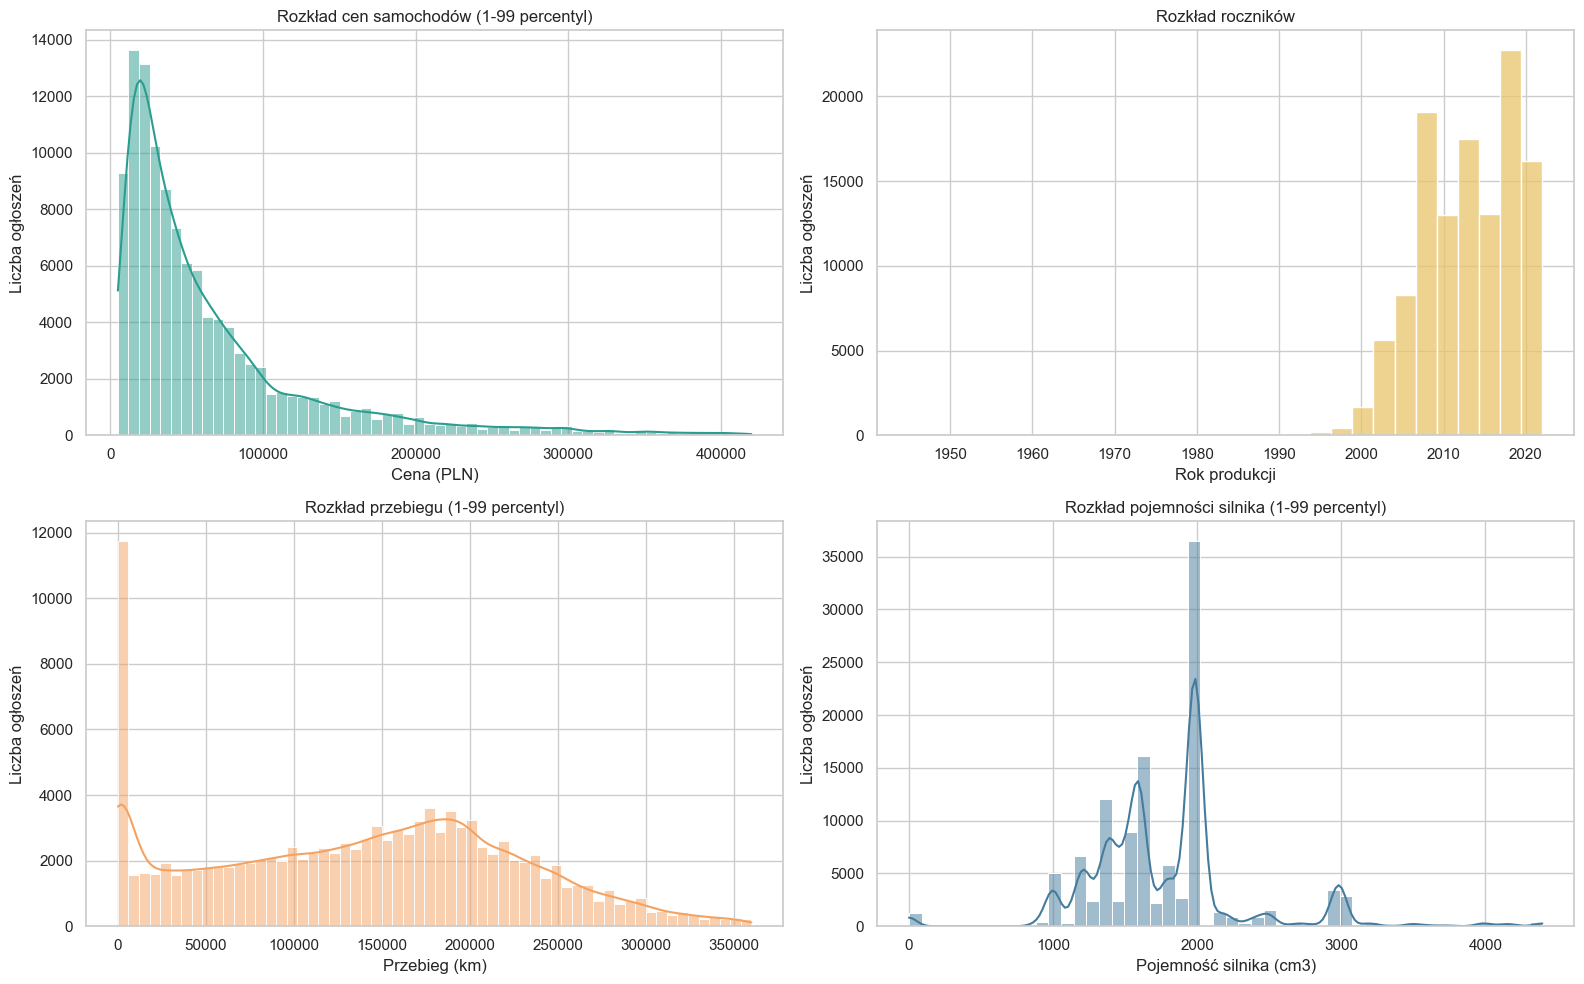

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

price_range = df["price"].quantile([0.01, 0.99])
mileage_range = df["mileage"].quantile([0.01, 0.99])
engine_range = df["vol_engine"].quantile([0.01, 0.99])

price_plot = df[df["price"].between(price_range.iloc[0], price_range.iloc[1])]
mileage_plot = df[df["mileage"].between(mileage_range.iloc[0], mileage_range.iloc[1])]
engine_plot = df[df["vol_engine"].between(engine_range.iloc[0], engine_range.iloc[1])]

sns.histplot(price_plot["price"], bins=60, kde=True, ax=axes[0, 0], color="#2A9D8F")
axes[0, 0].set_title("Rozkład cen samochodów (1-99 percentyl)")
axes[0, 0].set_xlabel("Cena (PLN)")
axes[0, 0].set_ylabel("Liczba ogłoszeń")

sns.histplot(df["year"], bins=30, ax=axes[0, 1], color="#E9C46A")
axes[0, 1].set_title("Rozkład roczników")
axes[0, 1].set_xlabel("Rok produkcji")
axes[0, 1].set_ylabel("Liczba ogłoszeń")

sns.histplot(mileage_plot["mileage"], bins=60, kde=True, ax=axes[1, 0], color="#F4A261")
axes[1, 0].set_title("Rozkład przebiegu (1-99 percentyl)")
axes[1, 0].set_xlabel("Przebieg (km)")
axes[1, 0].set_ylabel("Liczba ogłoszeń")

sns.histplot(engine_plot["vol_engine"], bins=50, kde=True, ax=axes[1, 1], color="#457B9D")
axes[1, 1].set_title("Rozkład pojemności silnika (1-99 percentyl)")
axes[1, 1].set_xlabel("Pojemność silnika (cm3)")
axes[1, 1].set_ylabel("Liczba ogłoszeń")

plt.tight_layout()
plt.show()


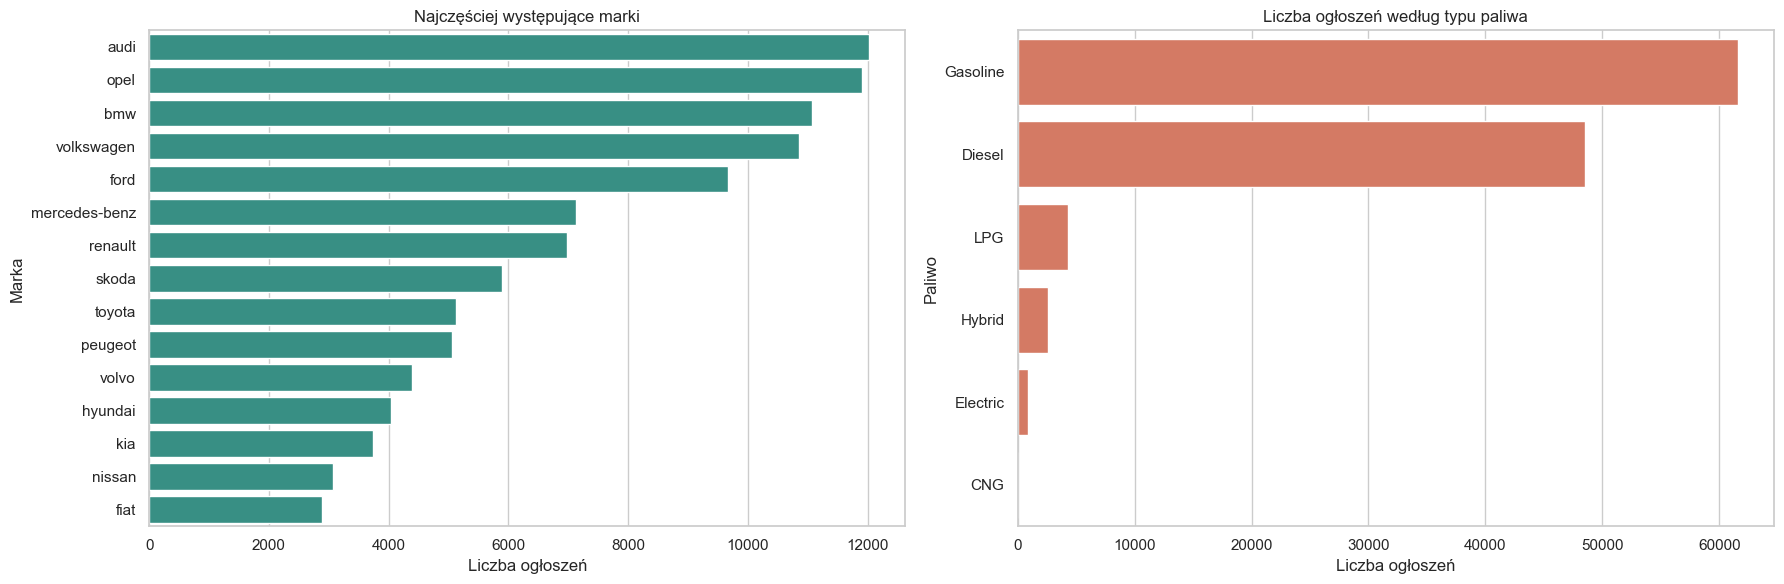

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

brand_order = df["mark"].value_counts().head(15).index
sns.countplot(data=df[df["mark"].isin(brand_order)], y="mark", order=brand_order, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Najczęściej występujące marki")
axes[0].set_xlabel("Liczba ogłoszeń")
axes[0].set_ylabel("Marka")

fuel_order = df["fuel"].value_counts().index
sns.countplot(data=df, y="fuel", order=fuel_order, ax=axes[1], color="#E76F51")
axes[1].set_title("Liczba ogłoszeń według typu paliwa")
axes[1].set_xlabel("Liczba ogłoszeń")
axes[1].set_ylabel("Paliwo")

plt.tight_layout()
plt.show()


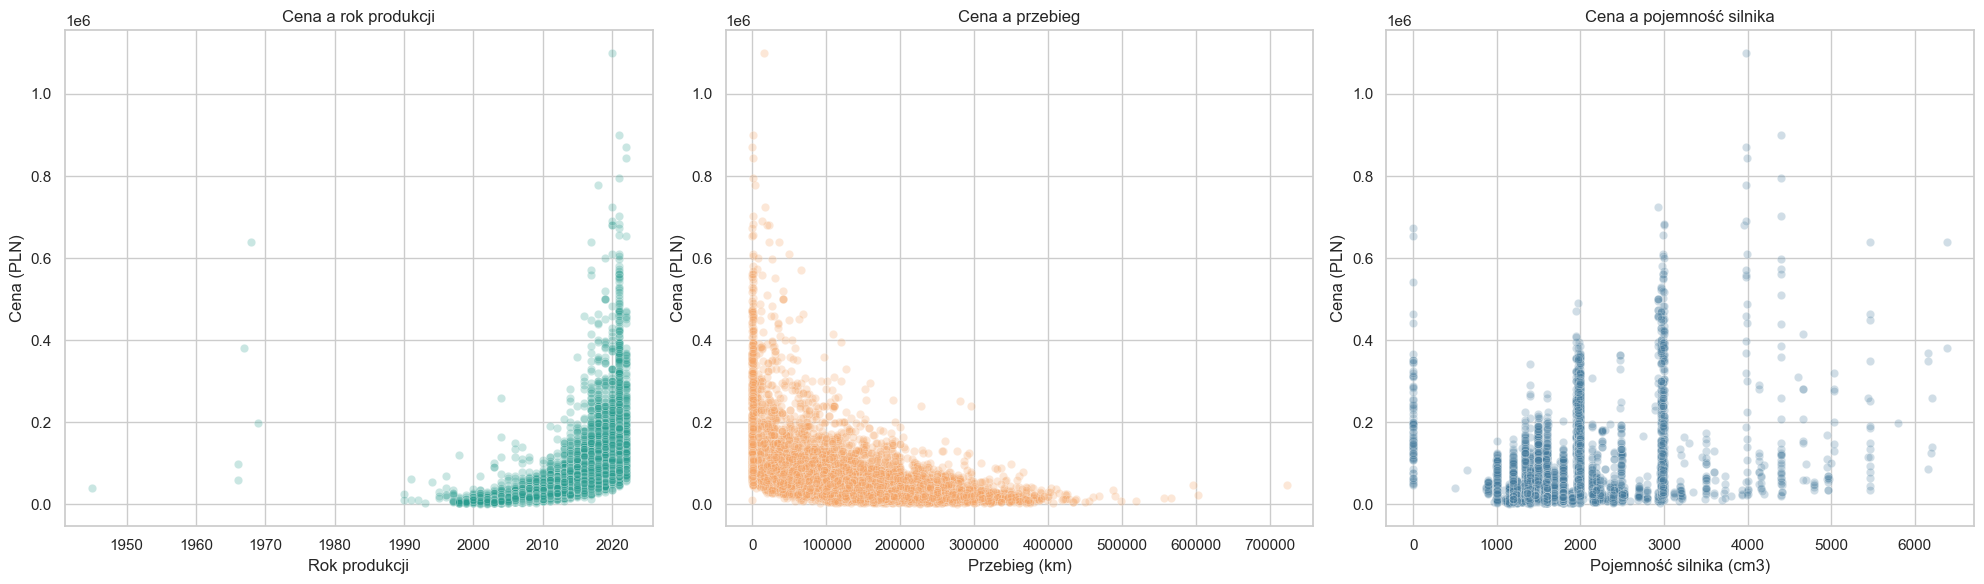

In [21]:
sample_df = df.sample(min(8000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(data=sample_df, x="year", y="price", alpha=0.25, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Cena a rok produkcji")
axes[0].set_xlabel("Rok produkcji")
axes[0].set_ylabel("Cena (PLN)")

sns.scatterplot(data=sample_df, x="mileage", y="price", alpha=0.25, ax=axes[1], color="#F4A261")
axes[1].set_title("Cena a przebieg")
axes[1].set_xlabel("Przebieg (km)")
axes[1].set_ylabel("Cena (PLN)")

sns.scatterplot(data=sample_df, x="vol_engine", y="price", alpha=0.25, ax=axes[2], color="#457B9D")
axes[2].set_title("Cena a pojemność silnika")
axes[2].set_xlabel("Pojemność silnika (cm3)")
axes[2].set_ylabel("Cena (PLN)")

plt.tight_layout()
plt.show()


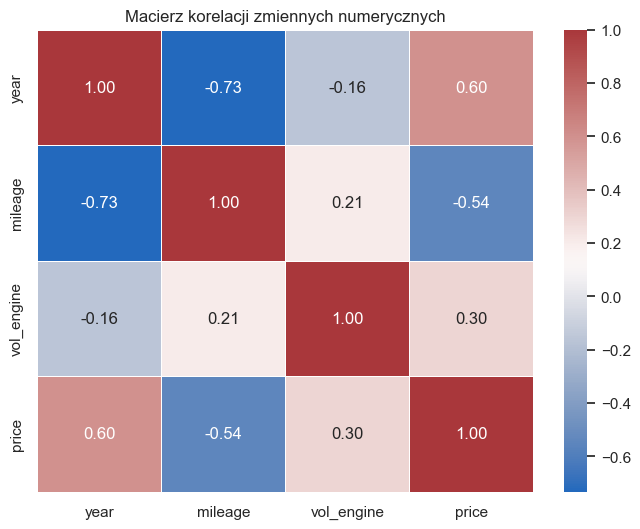

,korelacja_z_cena
price,1.00
year,0.60
vol_engine,0.30
mileage,-0.54


In [14]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5)
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

display(corr_matrix["price"].sort_values(ascending=False).to_frame("korelacja_z_cena"))


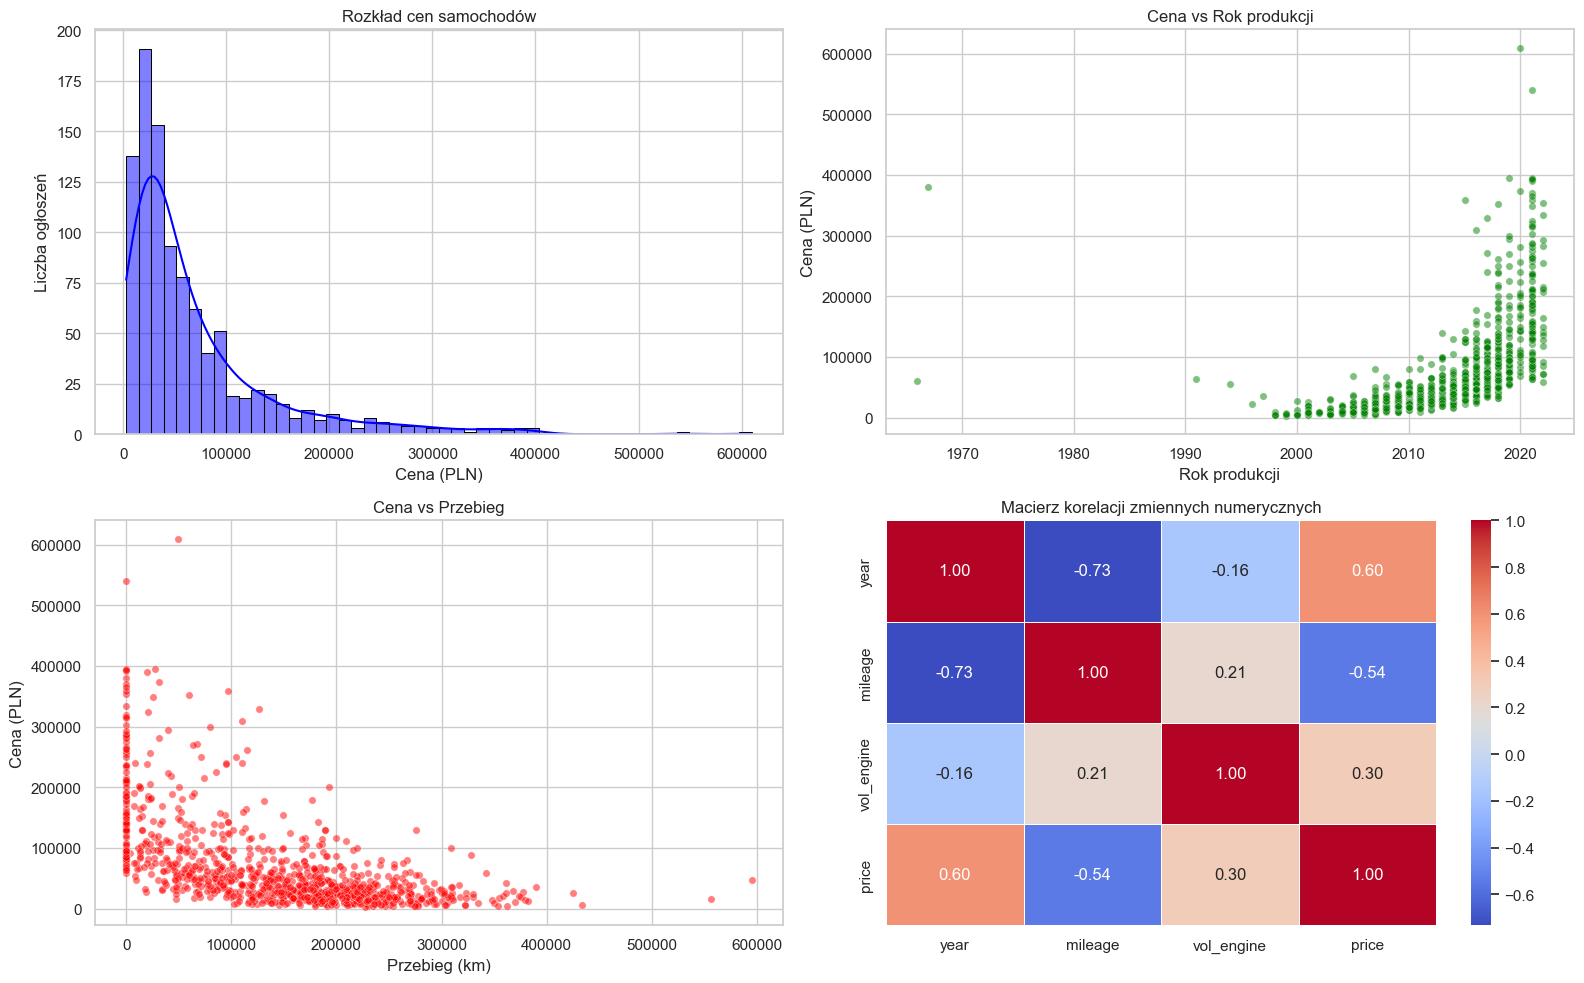

In [22]:
plot_df = df.sample(min(1000, len(df)), random_state=42)
numeric_cols = ["year", "mileage", "vol_engine", "price"]
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(plot_df["price"], bins=50, kde=True, ax=axes[0, 0], color="blue", alpha=0.5, edgecolor="black")
axes[0, 0].set_title("Rozkład cen samochodów")
axes[0, 0].set_xlabel("Cena (PLN)")
axes[0, 0].set_ylabel("Liczba ogłoszeń")

sns.scatterplot(data=plot_df, x="year", y="price", ax=axes[0, 1], color="green", alpha=0.5, s=28)
axes[0, 1].set_title("Cena vs Rok produkcji")
axes[0, 1].set_xlabel("Rok produkcji")
axes[0, 1].set_ylabel("Cena (PLN)")

sns.scatterplot(data=plot_df, x="mileage", y="price", ax=axes[1, 0], color="red", alpha=0.5, s=28)
axes[1, 0].set_title("Cena vs Przebieg")
axes[1, 0].set_xlabel("Przebieg (km)")
axes[1, 0].set_ylabel("Cena (PLN)")

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title("Macierz korelacji zmiennych numerycznych")

plt.tight_layout()
plt.show()


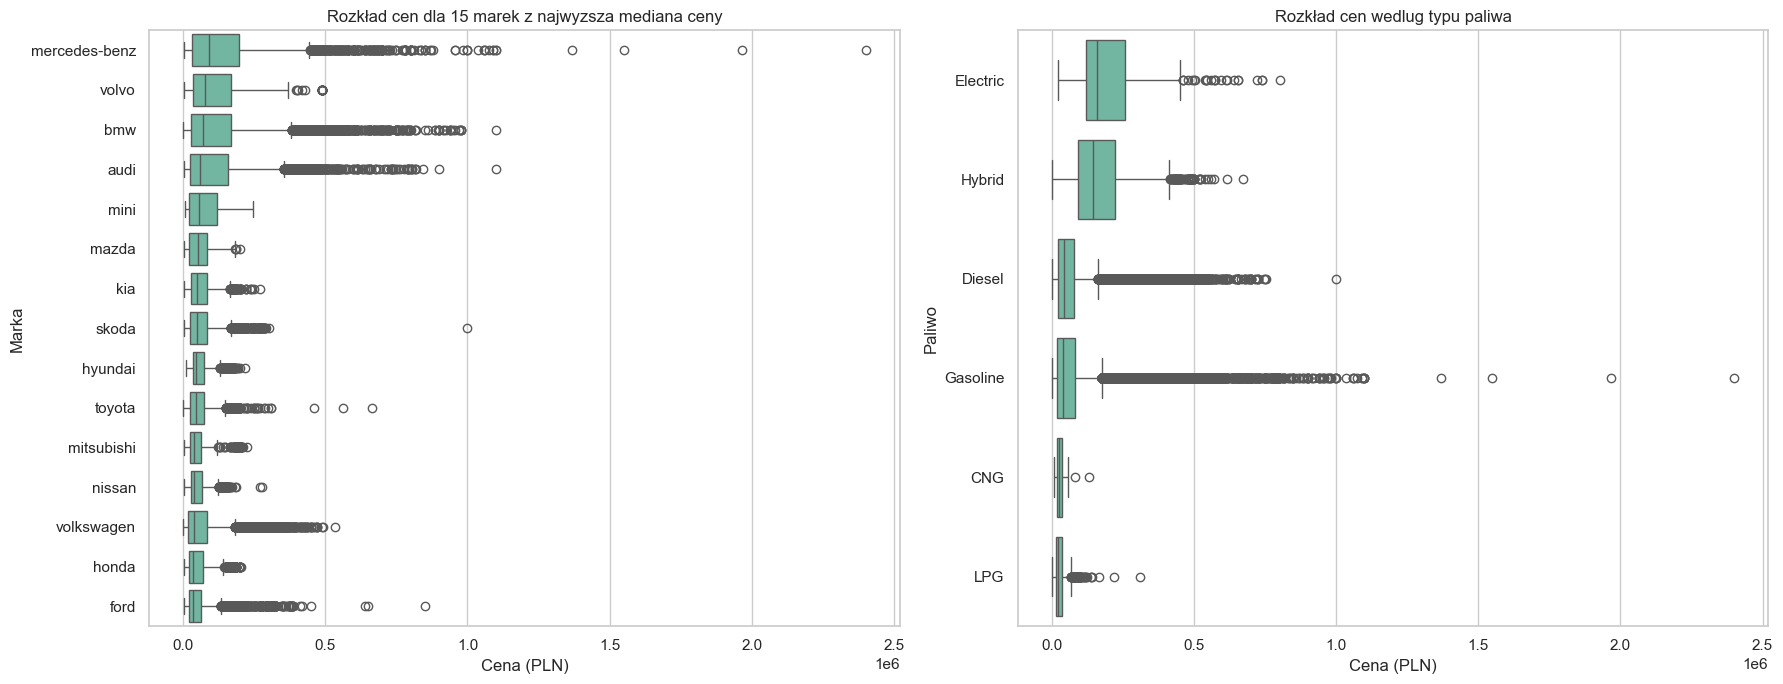

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

brand_price_order = df.groupby("mark")["price"].median().sort_values(ascending=False).head(15).index
sns.boxplot(data=df[df["mark"].isin(brand_price_order)], x="price", y="mark", order=brand_price_order, ax=axes[0])
axes[0].set_title("Rozkład cen dla 15 marek z najwyzsza mediana ceny")
axes[0].set_xlabel("Cena (PLN)")
axes[0].set_ylabel("Marka")

fuel_price_order = df.groupby("fuel")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="price", y="fuel", order=fuel_price_order, ax=axes[1])
axes[1].set_title("Rozkład cen według typu paliwa")
axes[1].set_xlabel("Cena (PLN)")
axes[1].set_ylabel("Paliwo")

plt.tight_layout()
plt.show()


### Wnioski z analizy danych

- Zbiór zawiera dużą liczbę rzeczywistych obserwacji, dlatego nadaje się do zastosowania metod uczenia maszynowego.
- Zmienna docelowa `price` jest numeryczna, więc problem jest zadaniem regresji.
- Dane zawierają zarówno zmienne numeryczne, jak i kategoryczne, dlatego przed modelowaniem potrzebne będzie kodowanie zmiennych tekstowych.
- Kolumna `generation_name` ma braki danych, które należy obsłużyć, np. przez uzupełnienie wartością `unknown` lub pominięcie tej cechy w prostszych modelach.
- Najważniejsze cechy biznesowo to prawdopodobnie `year`, `mileage`, `vol_engine`, `mark`, `model` oraz `fuel`.
- Zależności między ceną a cechami pojazdu mogą być nieliniowe, dlatego oprócz regresji liniowej warto rozważyć modele drzewiaste i gradient boosting.


## 3. Sformułowanie hipotezy

**Hipoteza główna:** na podstawie historycznych danych ogłoszeniowych można zbudować model regresyjny, który przewidzi cenę samochodu używanego w Polsce z akceptowalną dokładnością biznesową.

**Kryterium potwierdzenia hipotezy:** hipoteza zostanie uznana za potwierdzona, jeśli najlepszy wytrenowany model osiągnie na zbiorze testowym co najmniej jedno z poniższych kryteriów:

- `R2 >= 0.80`, czyli model wyjaśni co najmniej 80% zmienności ceny,
- `MAPE <= 20%`, czyli przeciętny procentowy błąd predykcji nie przekroczy 20%.

**Hipotezy pomocnicze:**

1. Rok produkcji będzie dodatnio związany z ceną samochodu.
2. Przebieg będzie ujemnie związany z ceną samochodu.
3. Marka, model i typ paliwa będą istotnie poprawiać jakość predykcji względem modelu wykorzystującego wyłącznie cechy numeryczne.


## 4. Aktualny stan wiedzy

Przewidywanie cen samochodów używanych jest klasycznym problemem regresji w uczeniu maszynowym. W praktyce wykorzystuje się dane tabelaryczne pochodzące z ogłoszeń: markę, model, rocznik, przebieg, typ paliwa, pojemność silnika, lokalizację i inne cechy techniczne.

**Regresja liniowa** jest często traktowana jako model bazowy. Jest szybka i łatwa w interpretacji, ale gorzej radzi sobie z nieliniowymi zależnościami oraz interakcjami między cechami, np. tym, że przebieg może mieć różne znaczenie dla różnych marek i roczników.

**Modele drzewiaste**, takie jak Decision Tree i Random Forest, są popularne dla danych tabelarycznych, ponieważ potrafią modelować nieliniowości, zależności progowe i interakcje między zmiennymi. Random Forest ogranicza przeuczenie pojedynczego drzewa przez uśrednianie wielu modeli.

**Gradient boosting**, np. XGBoost, LightGBM lub GradientBoostingRegressor, jest obecnie jednym z najczęściej stosowanych podejść dla danych tabelarycznych. Modele te budują wiele słabych drzew sekwencyjnie, a każde kolejne drzewo poprawia błędy poprzednich. Zwykle osiągają bardzo dobre wyniki, ale wymagają strojenia hiperparametrów.

**Wyzwania dla tego problemu** obejmują: braki i błędy w danych, wartości odstające, nierównomierną reprezentację marek i modeli, lokalne różnice cenowe oraz czynniki nieuwzględnione w danych, np. stan techniczny, historia wypadkowa czy wyposażenie pojazdu.


## 5. Analiza potencjalnych kandydatów na model

Poniżej porównano modele, które mogą zostać użyte do przewidywania ceny samochodu. Do implementacji końcowej warto wybrać jeden model prostszy jako punkt odniesienia oraz jeden model bardziej zaawansowany, który ma większy potencjał jakości predykcji.


In [17]:
model_candidates = pd.DataFrame([
    {
        "Model": "Linear Regression / Ridge Regression",
        "Sposób działania": "Dopasowuje liniową zależność między cechami a ceną; Ridge dodaje regularyzację ograniczającą zbyt duże współczynniki.",
        "Zalety": "Szybki, prosty, interpretowalny, dobry model bazowy.",
        "Wady": "Słabo odwzorowuje nieliniowości i interakcje; wymaga kodowania zmiennych kategorycznych i skalowania przy niektórych wariantach.",
        "Dopasowanie do problemu": "Dobre jako baseline, ale prawdopodobnie za prosty jako model docelowy."
    },
    {
        "Model": "Decision Tree Regressor",
        "Sposób działania": "Dzieli dane na kolejne warunki decyzyjne, np. rocznik, przebieg, marka, aby minimalizować błąd predykcji w liściach.",
        "Zalety": "Czytelny, obsługuje nieliniowości, nie wymaga skalowania cech.",
        "Wady": "Łatwo się przeucza; pojedyncze drzewo bywa niestabilne.",
        "Dopasowanie do problemu": "Przydatny porównawczo, ale raczej słabszy niż modele zespołowe."
    },
    {
        "Model": "Random Forest Regressor",
        "Sposób działania": "Buduje wiele drzew decyzyjnych na losowych próbkach danych i uśrednia ich predykcje.",
        "Zalety": "Dobrze radzi sobie z nieliniowościami, odporniejszy na przeuczenie niż pojedyncze drzewo, działa dobrze na danych tabelarycznych.",
        "Wady": "Mniej interpretowalny, wolniejszy dla dużych zbiorów, może wymagać dużo pamięci.",
        "Dopasowanie do problemu": "Bardzo dobre; naturalny kandydat dla tego typu danych."
    },
    {
        "Model": "Gradient Boosting / XGBoost / LightGBM",
        "Sposób działania": "Buduje drzewa sekwencyjnie, gdzie kolejne modele poprawiają błędy poprzednich.",
        "Zalety": "Często bardzo wysoka jakość predykcji dla danych tabelarycznych; dobrze modeluje złożone zależności.",
        "Wady": "Wymaga strojenia hiperparametrów; większe ryzyko przeuczenia przy złych ustawieniach; wolniejszy trening.",
        "Dopasowanie do problemu": "Bardzo dobre; prawdopodobnie najlepszy kandydat do modelu końcowego."
    },
    {
        "Model": "KNN Regressor",
        "Sposób działania": "Wyznacza cenę na podstawie cen najbardziej podobnych samochodów w zbiorze treningowym.",
        "Zalety": "Intuicyjny, prosty do zrozumienia, może działać dobrze lokalnie dla podobnych ofert.",
        "Wady": "Wrażliwy na skalowanie, duży koszt predykcji, słabszy przy wielu cechach kategorycznych i dużym zbiorze.",
        "Dopasowanie do problemu": "Średnie; może być modelem porównawczym, ale nie najlepszym wyborem produkcyjnym."
    },
])

display(model_candidates)


,Model,Sposób działania,Zalety,Wady,Dopasowanie do problemu
0,Linear Regression / Ridge Regression,Dopasowuje liniową zależność między cechami a ...,"Szybki, prosty, interpretowalny, dobry model b...",Słabo odwzorowuje nieliniowości i interakcje; ...,"Dobre jako baseline, ale prawdopodobnie za pro..."
1,Decision Tree Regressor,"Dzieli dane na kolejne warunki decyzyjne, np. ...","Czytelny, obsługuje nieliniowości, nie wymaga ...",Łatwo się przeucza; pojedyncze drzewo bywa nie...,"Przydatny porównawczo, ale raczej słabszy niż ..."
2,Random Forest Regressor,Buduje wiele drzew decyzyjnych na losowych pro...,"Dobrze radzi sobie z nieliniowościami, odporni...","Mniej interpretowalny, wolniejszy dla dużych z...",Bardzo dobre; naturalny kandydat dla tego typu...
3,Gradient Boosting / XGBoost / LightGBM,"Buduje drzewa sekwencyjnie, gdzie kolejne mode...",Często bardzo wysoka jakość predykcji dla dany...,Wymaga strojenia hiperparametrów; większe ryzy...,Bardzo dobre; prawdopodobnie najlepszy kandyda...
4,KNN Regressor,Wyznacza cenę na podstawie cen najbardziej pod...,"Intuicyjny, prosty do zrozumienia, może działa...","Wrażliwy na skalowanie, duży koszt predykcji, ...","Średnie; może być modelem porównawczym, ale ni..."


### Rekomendacja modeli do implementacji

Do części implementacyjnej rekomendowane są dwa modele:

1. **Ridge Regression** jako prosty, interpretowalny model bazowy.
2. **Random Forest Regressor** albo **Gradient Boosting Regressor** jako model zaawansowany, lepiej dopasowany do nieliniowych zależności w danych.

Strojenie hiperparametrów warto wykonać dla lepszego z dwóch zaimplementowanych modeli, zgodnie z wymaganiami projektu. Do oceny wyników należy użyć metryk regresyjnych: `MAE`, `RMSE`, `R2` oraz opcjonalnie `MAPE`, ponieważ cena samochodu jest zmienna numeryczna.
